In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
ds = xr.open_dataset('/glade/work/acruz/Caribbean_Heat_data/ERA5/dailymax_HI.nc')
ds

<xarray.Dataset> Size: 1GB
Dimensions:       (time: 31471, latitude: 82, longitude: 121)
Coordinates:
  * time          (time) datetime64[ns] 252kB 1940-01-01 ... 2026-02-28
  * latitude      (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude     (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0
Data variables:
    HI_daily_max  (time, latitude, longitude) float32 1GB ...

In [3]:
HI_dmax_clim = ds.groupby('time.month').mean(dim='time')
HI_dmax_clim = HI_dmax_clim['HI_daily_max'].rename('HI_daily_max_clim')
HI_dmax_clim

<xarray.DataArray 'HI_daily_max_clim' (month: 12, latitude: 82, longitude: 121)> Size: 476kB
array([[[81.73618 , 82.00914 , 82.311554, ..., 88.55383 , 87.51155 ,
         84.772224],
        [81.28596 , 81.60507 , 81.98476 , ..., 87.81538 , 84.59711 ,
         80.79885 ],
        [80.9382  , 81.20753 , 81.52631 , ..., 82.65165 , 80.880325,
         81.276566],
        ...,
        [68.764755, 68.872856, 68.96768 , ..., 71.98404 , 71.96515 ,
         71.97867 ],
        [68.213264, 68.30589 , 68.38949 , ..., 71.73967 , 71.73571 ,
         71.73682 ],
        [67.67302 , 67.75469 , 67.79707 , ..., 71.50498 , 71.499245,
         71.51562 ]],

       [[83.38062 , 83.682175, 83.97325 , ..., 88.83337 , 87.7432  ,
         84.95143 ],
        [82.716675, 83.07454 , 83.43201 , ..., 87.96016 , 84.73106 ,
         80.6141  ],
        [82.062614, 82.3903  , 82.7527  , ..., 82.84658 , 80.60874 ,
         80.89952 ],
...
        [74.27266 , 74.30786 , 74.361046, ..., 76.45548 , 76.432625,
         76.44584 ],
        [73.89006 , 73.933914, 73.97508 , ..., 76.25665 , 76.24048 ,
         76.2347  ],
        [73.53403 , 73.562096, 73.56584 , ..., 76.04454 , 76.03295 ,
         76.052   ]],

       [[81.69691 , 81.84369 , 82.01459 , ..., 90.59121 , 89.61248 ,
         86.811005],
        [81.61029 , 81.79797 , 82.00513 , ..., 90.03962 , 86.55716 ,
         82.90124 ],
        [81.55613 , 81.691   , 81.87802 , ..., 84.6105  , 82.97231 ,
         83.588936],
        ...,
        [70.90199 , 70.97028 , 71.0396  , ..., 73.6264  , 73.61046 ,
         73.62862 ],
        [70.43856 , 70.49947 , 70.557724, ..., 73.40391 , 73.4055  ,
         73.408394],
        [69.99601 , 70.05038 , 70.06632 , ..., 73.18413 , 73.18916 ,
         73.21051 ]]], shape=(12, 82, 121), dtype=float32)
Coordinates:
  * month      (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * latitude   (latitude) float64 656B 7.75 8.0 8.25 8.5 ... 27.5 27.75 28.0
  * longitude  (longitude) float64 968B -89.0 -88.75 -88.5 ... -59.25 -59.0

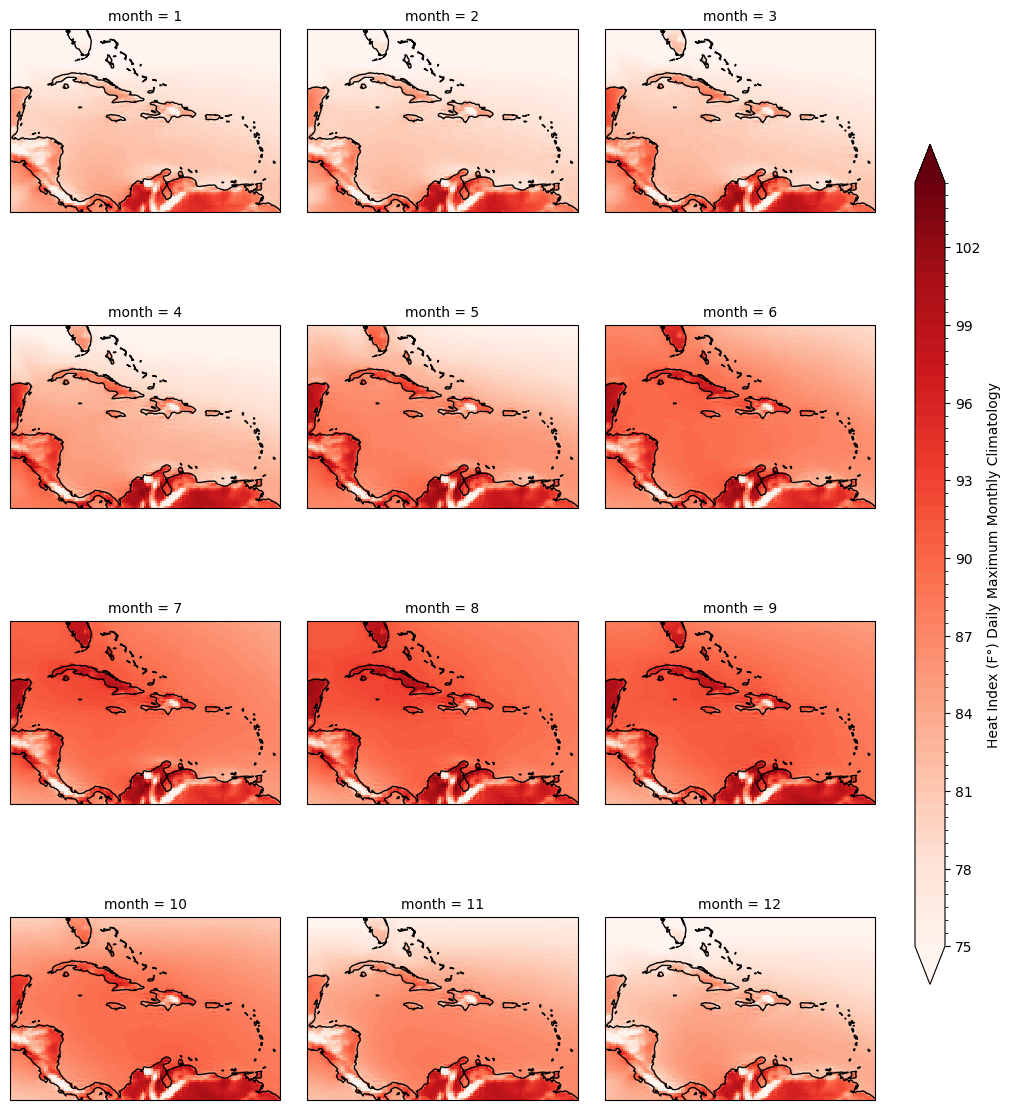

In [7]:
hiclim_plot = HI_dmax_clim.isel(month=np.arange(0, 12, 1)).plot(col='month',
                                                         col_wrap=3,
                                                         transform=ccrs.PlateCarree(),
                                                         cmap='Reds',
                                                         levels=np.arange(75, 105, 0.5),
                                                         subplot_kws={'projection': ccrs.PlateCarree(central_longitude=-70)},
                                                         add_colorbar=False
                                                               )
cax = hiclim_plot.fig.add_axes([0.92, 0.15, 0.03, 0.70])
hiclim_plot.fig.colorbar(hiclim_plot.axs.flat[0].collections[0], cax=cax, label='Heat Index (F°) Daily Maximum Monthly Climatology')
hiclim_plot.map(lambda: plt.gca().coastlines())
plt.subplots_adjust(wspace=0.1, hspace=0.05, right=0.88)

In [238]:
HI_dmax_clim.to_netcdf('/glade/work/acruz/Caribbean_Heat_data/ERA5/HI_dmaxclim.nc')